# CSI4142 Assignment 4

1. Andrew Pham - 300226985

2. Kevin Yao - 300295024

Work split:
- Kevin: Studies 2 & 3
- Andrew: Part 1 and studies 1 & 4


## Dataset

- Name: The Movies Dataset
- Author: Published on Kaggle by Rounak Banik
- Purpose: Contains metadata for movies listed in the Full MovieLens Dataset, as well as ratings
- Shape:
    - Metadata: (45466, 24)
    - Ratings: (26024289, 4)

https://www.kaggle.com/datasets/rounakbanik/the-movies-dataset 


## Part 1 - Data Preparation

In [3]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
metadata_file = "movies_metadata.csv"
ratings_file = "ratings.csv"

metadata_df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "rounakbanik/the-movies-dataset",
    path=metadata_file,
)

ratings_df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "rounakbanik/the-movies-dataset",
    path=ratings_file,
)

print("Metadata shape:", metadata_df.shape)
print("Ratings shape:", ratings_df.shape)

print("Metadata df:")
display(metadata_df.head())

print("Ratings df:")
display(ratings_df.head())

ValueError: Error reading file: 'utf-8' codec can't decode byte 0xa2 in position 10: invalid start byte

In [ ]:
metadata_df.columns

Index(['adult', 'belongs_to_collection', 'budget', 'genres', 'homepage', 'id',
       'imdb_id', 'original_language', 'original_title', 'overview',
       'popularity', 'poster_path', 'production_companies',
       'production_countries', 'release_date', 'revenue', 'runtime',
       'spoken_languages', 'status', 'tagline', 'title', 'video',
       'vote_average', 'vote_count'],
      dtype='str')

In [ ]:
metadata_df["status"].value_counts()

status
Released           45014
Rumored              230
Post Production       98
In Production         20
Planned               15
Canceled               2
Name: count, dtype: int64

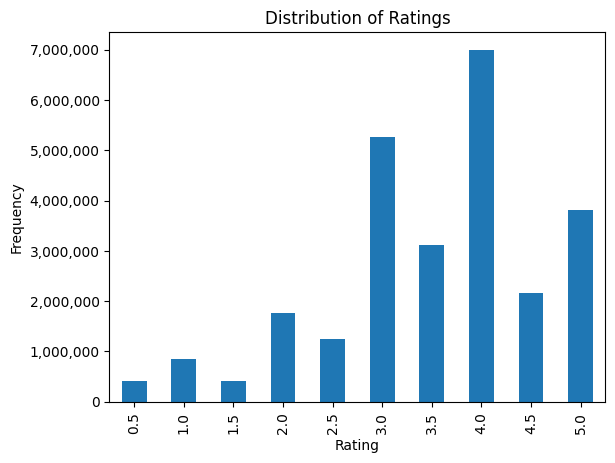

In [ ]:
# plot distribution of ratings
import matplotlib.ticker as mticker

ax = ratings_df["rating"].value_counts().sort_index().plot(kind="bar")
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.show()

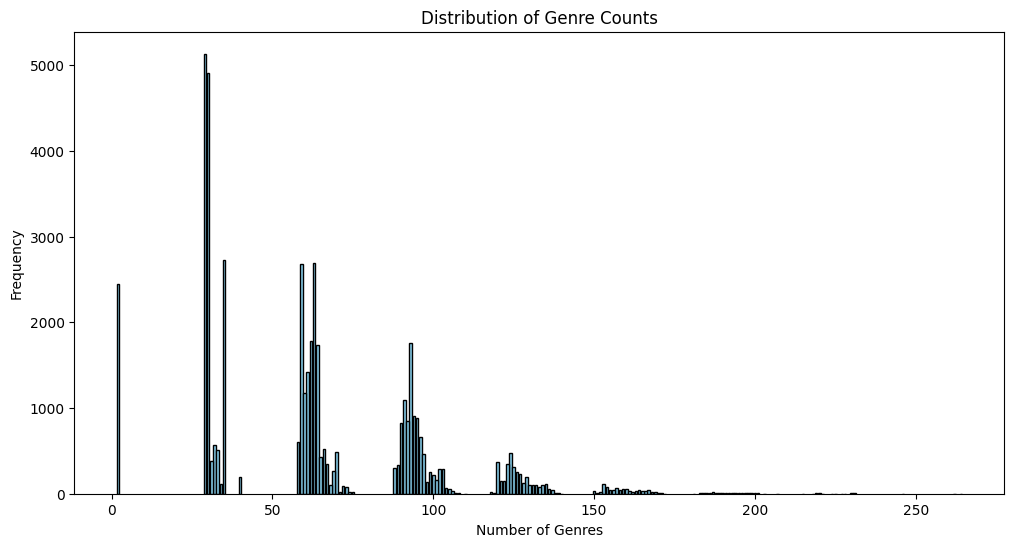

In [ ]:
metadata_df["genre_count"] = metadata_df["genres"].apply(lambda x: len(x))
genre_counts = metadata_df["genre_count"].value_counts()

# plot genre counts
plt.figure(figsize=(12, 6))
plt.bar(genre_counts.index, genre_counts.values, color="skyblue", edgecolor="black")
plt.title("Distribution of Genre Counts")
plt.xlabel("Number of Genres")
plt.ylabel("Frequency")
plt.show()

In [ ]:
# check nulls in any columns
# we'll decide later if we need to drop them
metadata_df.isnull().sum()

adult                        0
belongs_to_collection    40972
budget                       0
genres                       0
homepage                 37684
id                           0
imdb_id                     17
original_language           11
original_title               0
overview                   954
popularity                   5
poster_path                386
production_companies         3
production_countries         3
release_date                87
revenue                      6
runtime                    263
spoken_languages             6
status                      87
tagline                  25054
title                        6
video                        6
vote_average                 6
vote_count                   6
genre_count                  0
dtype: int64

In [ ]:
# check for inconsistent release_date format
# convert to datetime and check for errors
metadata_df["release_date"] = pd.to_datetime(
    metadata_df["release_date"], errors="coerce"
)
# check for any errors
metadata_df[metadata_df["release_date"].isnull()]["release_date"]

711     NaT
734     NaT
3460    NaT
3628    NaT
5879    NaT
         ..
45148   NaT
45203   NaT
45338   NaT
45410   NaT
45461   NaT
Name: release_date, Length: 90, dtype: datetime64[us]

This study compares movies using five independent similarity measures: Jaccard on `genres`, Manhattan distance on `release_year`, Euclidean distance on the `budget` and `revenue` pair, Levenshtein edit distance on `title`, and cosine similarity on `overview` text.

In [ ]:
# check for nulls in any columns in ratings_df
ratings_df.isnull().sum()

userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

## Study 1: Movie Similarity Measures

In [ ]:
import ast
import re

from sklearn.feature_extraction.text import TfidfVectorizer


# Create a cleaned working copy for the similarity experiments.
similarity_df = metadata_df.copy()

# drop rows with null release_date
start_count = len(similarity_df)
similarity_df = similarity_df[similarity_df["release_date"].notna()]
end_count = len(similarity_df)
print(f"Dropped {start_count - end_count} rows with null release dates")

similarity_df["popularity"] = pd.to_numeric(
    similarity_df["popularity"], errors="coerce"
)
similarity_df["budget"] = pd.to_numeric(similarity_df["budget"], errors="coerce")
similarity_df["revenue"] = pd.to_numeric(similarity_df["revenue"], errors="coerce")

similarity_df["release_date"] = pd.to_datetime(
    similarity_df["release_date"], errors="coerce"
)


similarity_df["release_year"] = similarity_df["release_date"].dt.year

Dropped 90 rows with null release dates


In [ ]:
def parse_names(value):
    if isinstance(value, list):
        return {
            item.get("name")
            for item in value
            if isinstance(item, dict) and item.get("name")
        }
    if isinstance(value, str) and value.strip():
        try:
            parsed = ast.literal_eval(value)
            if isinstance(parsed, list):
                return {
                    item.get("name")
                    for item in parsed
                    if isinstance(item, dict) and item.get("name")
                }
        except (ValueError, SyntaxError):
            return set()
    return set()


similarity_df["genre_set"] = similarity_df["genres"].apply(parse_names)

# normalize titles by lowercasing, removing non-alphanumeric characters, removing extra spaces
# normalize to make levenshtein distance more accurate
similarity_df["title_normalized"] = (
    similarity_df["title"]
    .fillna("")
    .str.lower()
    .str.replace(r"[^a-z0-9\s]", "", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)
similarity_df["overview_clean"] = similarity_df["overview"].fillna("")
overview_df = (
    similarity_df[similarity_df["overview_clean"].str.strip() != ""]
    .copy()
    .reset_index(drop=True)
)

display(overview_df[["title", "overview"]].head())
overview_df[["title_normalized", "overview_clean"]].head()

,title,overview
0,Toy Story,"Led by Woody, Andy's toys live happily in his ..."
1,Jumanji,When siblings Judy and Peter discover an encha...
2,Grumpier Old Men,A family wedding reignites the ancient feud be...
3,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom..."
4,Father of the Bride Part II,Just when George Banks has recovered from his ...


,title_normalized,overview_clean
0,toy story,"Led by Woody, Andy's toys live happily in his ..."
1,jumanji,When siblings Judy and Peter discover an encha...
2,grumpier old men,A family wedding reignites the ancient feud be...
3,waiting to exhale,"Cheated on, mistreated and stepped on, the wom..."
4,father of the bride part ii,Just when George Banks has recovered from his ...


In [ ]:
# vectorize with tf-idf for cosine similarity on overview

vectorizer = TfidfVectorizer(stop_words="english", max_features=5000)
overview_matrix = vectorizer.fit_transform(overview_df["overview_clean"])

In [ ]:
def get_reference_index(movie_title, df):
    matches = df[df["title"].fillna("").str.lower() == movie_title.lower()]
    if matches.empty:
        raise ValueError(f"Movie '{movie_title}' was not found in the dataset.")
    return matches.sort_values("popularity", ascending=False).index[0]


def format_results(results, score_column):
    columns = [
        "title",
        "release_year",
        "genres",
        "budget",
        "overview",
        "revenue",
        "vote_average",
        "popularity",
        score_column,
    ]
    return results.loc[:, columns].reset_index(drop=True)


########################################################
#                 similarity functions                 #
########################################################
def jaccard_genre_matches(movie_title, top_n=10):
    df = similarity_df[similarity_df["genre_set"].map(bool)].copy()
    ref_idx = get_reference_index(movie_title, df)
    reference_genres = df.at[ref_idx, "genre_set"]
    df["genre_jaccard"] = df["genre_set"].apply(
        lambda genres: (
            len(reference_genres & genres) / len(reference_genres | genres)
            if reference_genres | genres
            else 0
        )
    )
    results = (
        df.drop(index=ref_idx)
        .sort_values(["genre_jaccard", "popularity"], ascending=[False, False])
        .head(top_n)
    )
    return format_results(results, "genre_jaccard")


def manhattan_release_matches(movie_title, top_n=10):
    df = similarity_df.dropna(subset=["release_year"]).copy()
    ref_idx = get_reference_index(movie_title, df)
    reference_year = df.at[ref_idx, "release_year"]
    df["release_year_distance"] = (df["release_year"] - reference_year).abs()
    results = (
        df.drop(index=ref_idx)
        .sort_values(["release_year_distance", "popularity"], ascending=[True, False])
        .head(top_n)
    )
    return format_results(results, "release_year_distance")


def euclidean_financial_matches(movie_title, top_n=10):
    # we use "finances" as a combination of budget and revenue,
    # and log transform to make it more normal
    # this is so that we have two dimensions to compare, and we can use euclidean distance
    # otherwise on one column, it would reduce to manhattan distance
    df = similarity_df.dropna(subset=["budget", "revenue"]).copy()
    df = df[(df["budget"] > 0) & (df["revenue"] > 0)].copy()
    ref_idx = get_reference_index(movie_title, df)
    financial_values = np.log1p(df[["budget", "revenue"]])
    reference_point = financial_values.loc[ref_idx]
    df["financial_distance"] = np.sqrt(
        ((financial_values - reference_point) ** 2).sum(axis=1)
    )
    results = (
        df.drop(index=ref_idx)
        .sort_values(["financial_distance", "popularity"], ascending=[True, False])
        .head(top_n)
    )
    return format_results(results, "financial_distance")


# code from: https://www.geeksforgeeks.org/dsa/introduction-to-levenshtein-distance/
def levenshtein_distance(str1, str2):
    # Get the lengths of the input strings
    m = len(str1)
    n = len(str2)

    # Initialize two rows for dynamic programming
    prev_row = [j for j in range(n + 1)]
    curr_row = [0] * (n + 1)

    # Dynamic programming to fill the matrix
    for i in range(1, m + 1):
        # Initialize the first element of the current row
        curr_row[0] = i

        for j in range(1, n + 1):
            if str1[i - 1] == str2[j - 1]:
                # Characters match, no operation needed
                curr_row[j] = prev_row[j - 1]
            else:
                # Choose the minimum cost operation
                curr_row[j] = 1 + min(
                    curr_row[j - 1],  # Insert
                    prev_row[j],  # Remove
                    prev_row[j - 1],  # Replace
                )

        # Update the previous row with the current row
        prev_row = curr_row.copy()

    # The final element in the last row contains the Levenshtein distance
    return curr_row[n]


def levenshtein_title_matches(movie_title, top_n=10):
    df = similarity_df[similarity_df["title_normalized"] != ""].copy()
    ref_idx = get_reference_index(movie_title, df)
    reference_title = df.at[ref_idx, "title_normalized"]
    df["title_edit_distance"] = df["title_normalized"].apply(
        lambda value: levenshtein_distance(reference_title, value)
    )
    results = (
        df.drop(index=ref_idx)
        .sort_values(["title_edit_distance", "popularity"], ascending=[True, False])
        .head(top_n)
    )
    return format_results(results, "title_edit_distance")


def cosine_overview_matches(movie_title, top_n=10):
    df = overview_df.copy()
    ref_idx = get_reference_index(movie_title, df)
    similarity_scores = (overview_matrix[ref_idx] @ overview_matrix.T).toarray().ravel()
    df["overview_cosine_similarity"] = similarity_scores
    results = (
        df.drop(index=ref_idx)
        .sort_values(
            ["overview_cosine_similarity", "popularity"], ascending=[False, False]
        )
        .head(top_n)
    )
    return format_results(results, "overview_cosine_similarity")

In [ ]:
requests = [
    (
        "Show me movies with similar genres to 'The Truman Show'",
        jaccard_genre_matches,
        "The Truman Show",
    ),
    (
        "Show me movies released around the same time as 'Her'",
        manhattan_release_matches,
        "Her",
    ),
    (
        "Show me movies with a similar budget and revenue profile to 'Black Swan'",
        euclidean_financial_matches,
        "Black Swan",
    ),
    (
        "Show me movies with a similar title to 'Fight Club'",
        levenshtein_title_matches,
        "Fight Club",
    ),
    (
        "Show me movies with a similar plot description to 'The Dark Knight'",
        cosine_overview_matches,
        "The Dark Knight",
    ),
]

for prompt, matcher, movie_title in requests:
    print(prompt)
    display(matcher(movie_title, top_n=10))
    print()

Show me movies with similar genres to 'The Truman Show'


,title,release_year,genres,budget,overview,revenue,vote_average,popularity,genre_jaccard
0,Life Is Beautiful,1997,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",20000000,A touching story of an Italian book seller of ...,229400000.0,8.3,39.394970,1.0
1,Rough Night,2017,"[{'id': 18, 'name': 'Drama'}, {'id': 35, 'name...",20000000,Five best friends from college reunite 10 year...,45056771.0,5.6,24.317924,1.0
2,Birdman,2014,"[{'id': 18, 'name': 'Drama'}, {'id': 35, 'name...",18000000,A fading actor best known for his portrayal of...,103215094.0,7.4,18.193263,1.0
3,Two Is a Family,2016,"[{'id': 18, 'name': 'Drama'}, {'id': 35, 'name...",0,A man without attachments or responsibilities ...,1447740.0,7.6,17.181564,1.0
4,Beaches,1988,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",0,A privileged rich debutante and a cynical stru...,57041866.0,6.5,16.179384,1.0
5,The Intouchables,2011,"[{'id': 18, 'name': 'Drama'}, {'id': 35, 'name...",13000000,A true story of two men who should never have ...,426480871.0,8.2,16.086919,1.0
6,The Opposite of Sex,1998,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",5000000,A 16-year-old girl visits her gay half-brother...,5879254.0,5.9,14.734622,1.0
7,The Grand Budapest Hotel,2014,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",30000000,The Grand Budapest Hotel tells of a legendary ...,174600318.0,8.0,14.442048,1.0
8,Withnail & I,1987,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",0,Two 'resting' actors living in a squalid Camde...,0.0,7.4,14.316459,1.0
9,The Terminal,2004,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",60000000,Viktor Navorski is a man without a country; hi...,219417255.0,7.1,14.092373,1.0



Show me movies released around the same time as 'Her'


,title,release_year,genres,budget,overview,revenue,vote_average,popularity,release_year_distance
0,Thor: The Dark World,2013,"[{'id': 28, 'name': 'Action'}, {'id': 12, 'nam...",170000000,Thor fights to restore order across the cosmos...,6.445714e+08,6.8,34.905447,0
1,Pacific Rim,2013,"[{'id': 28, 'name': 'Action'}, {'id': 878, 'na...",180000000,"When legions of monstrous creatures, known as ...",4.076029e+08,6.7,33.949359,0
2,12 Years a Slave,2013,"[{'id': 18, 'name': 'Drama'}, {'id': 36, 'name...",20000000,"In the pre-Civil War United States, Solomon No...",1.870000e+08,7.9,30.316249,0
3,Dark Skies,2013,"[{'id': 878, 'name': 'Science Fiction'}, {'id'...",3500000,"From the producers of Paranormal Activity, Ins...",2.517432e+07,6.1,26.972326,0
4,World War Z,2013,"[{'id': 28, 'name': 'Action'}, {'id': 18, 'nam...",200000000,Life for former United Nations investigator Ge...,5.318650e+08,6.7,26.114917,0
5,The Hunger Games: Catching Fire,2013,"[{'id': 12, 'name': 'Adventure'}, {'id': 28, '...",130000000,Katniss Everdeen has returned home safe after ...,8.474235e+08,7.4,25.309139,0
6,The Hangover Part III,2013,"[{'id': 35, 'name': 'Comedy'}]",103000000,"This time, there's no wedding. No bachelor par...",3.620001e+08,6.0,25.085639,0
7,Despicable Me 2,2013,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",76000000,Gru is recruited by the Anti-Villain League to...,9.707619e+08,7.0,24.823550,0
8,Frozen,2013,"[{'id': 16, 'name': 'Animation'}, {'id': 12, '...",150000000,Young princess Anna of Arendelle dreams about ...,1.274219e+09,7.3,24.248243,0
9,Iron Man 3,2013,"[{'id': 28, 'name': 'Action'}, {'id': 12, 'nam...",200000000,When Tony Stark's world is torn apart by a for...,1.215440e+09,6.8,23.721243,0



Show me movies with a similar budget and revenue profile to 'Black Swan'


,title,release_year,genres,budget,overview,revenue,vote_average,popularity,financial_distance
0,The Conjuring,2013,"[{'id': 27, 'name': 'Horror'}, {'id': 53, 'nam...",13000000,Paranormal investigators Ed and Lorraine Warre...,318000141.0,7.4,14.901690,0.030363
1,Fatal Attraction,1987,"[{'id': 10749, 'name': 'Romance'}, {'id': 18, ...",14000000,A married man's one night stand comes back to ...,320145693.0,6.6,14.260779,0.077787
2,The Fault in Our Stars,2014,"[{'id': 10749, 'name': 'Romance'}, {'id': 18, ...",12000000,Despite the tumor-shrinking medical miracle th...,307166834.0,7.6,16.274653,0.103126
3,Beverly Hills Cop,1984,"[{'id': 28, 'name': 'Action'}, {'id': 35, 'nam...",15000000,Tough-talking Detroit cop Axel Foley heads to ...,316360478.0,6.8,8.503483,0.147446
4,American Beauty,1999,"[{'id': 18, 'name': 'Drama'}]",15000000,"Lester Burnham, a depressed suburban father in...",356296601.0,7.9,20.726578,0.165604
5,Top Gun,1986,"[{'id': 28, 'name': 'Action'}, {'id': 10749, '...",15000000,For Lieutenant Pete 'Maverick' Mitchell and hi...,356830601.0,6.7,20.301019,0.166363
6,Slumdog Millionaire,2008,"[{'id': 18, 'name': 'Drama'}, {'id': 10749, 'n...",15000000,Jamal Malik is an impoverished Indian teen who...,377910544.0,7.6,11.258181,0.201769
7,Spirited Away,2001,"[{'id': 14, 'name': 'Fantasy'}, {'id': 12, 'na...",15000000,A ten year old girl who wanders away from her ...,274925095.0,8.3,41.048867,0.226770
8,Dangal,2016,"[{'id': 18, 'name': 'Drama'}]",10400000,Dangal is an extraordinary true story based on...,310000000.0,8.0,8.792104,0.230025
9,The Intouchables,2011,"[{'id': 18, 'name': 'Drama'}, {'id': 35, 'name...",13000000,A true story of two men who should never have ...,426480871.0,8.2,16.086919,0.263152



Show me movies with a similar title to 'Fight Club'


,title,release_year,genres,budget,overview,revenue,vote_average,popularity,title_edit_distance
0,Flight Crew,2016,"[{'id': 18, 'name': 'Drama'}, {'id': 28, 'name...",10000000,"A story about bravery, self-sacrifice and huma...",27305571.0,6.8,5.420460,4
1,The Club,2015,"[{'id': 18, 'name': 'Drama'}]",0,In a secluded house in a small seaside town li...,52761.0,6.6,3.534068,4
2,The Club,1994,"[{'id': 27, 'name': 'Horror'}]",0,Time stops at midnight at the Senior Prom for ...,0.0,3.2,0.573367,4
3,The Club,1980,"[{'id': 18, 'name': 'Drama'}, {'id': 35, 'name...",0,Boardroom and dressing-room intrigues spill on...,0.0,5.8,0.475739,4
4,Fightville,2011,"[{'id': 99, 'name': 'Documentary'}]",0,FIGHTVILLE is about the art and sport of fight...,0.0,5.8,0.439409,4
5,Night Court,1932,"[{'id': 80, 'name': 'Crime'}, {'id': 18, 'name...",0,Judge Moffett is as crooked as they come and t...,0.0,8.0,0.144281,4
6,Eight Below,2006,"[{'id': 12, 'name': 'Adventure'}, {'id': 18, '...",40000000,"In the Antarctic, after an expedition with Dr....",120455994.0,6.7,13.876881,5
7,Flightplan,2005,"[{'id': 53, 'name': 'Thriller'}, {'id': 18, 'n...",55000000,"A claustrophobic, Hitchcockian thriller. A ber...",223387299.0,6.1,12.419851,5
8,Lights Out,2016,"[{'id': 27, 'name': 'Horror'}, {'id': 53, 'nam...",4900000,"When Rebecca left home, she thought she left h...",148868835.0,6.3,11.494907,5
9,Fighting,2009,"[{'id': 28, 'name': 'Action'}, {'id': 12, 'nam...",0,Small-town boy Shawn MacArthur has come to New...,32474120.0,5.5,7.036697,5



Show me movies with a similar plot description to 'The Dark Knight'


,title,release_year,genres,budget,overview,revenue,vote_average,popularity,overview_cosine_similarity
0,"Batman: The Dark Knight Returns, Part 2",2013,"[{'id': 28, 'name': 'Action'}, {'id': 16, 'nam...",3500000,Batman has stopped the reign of terror that Th...,0.000000e+00,7.9,12.576611,0.285180
1,The Dark Knight Rises,2012,"[{'id': 28, 'name': 'Action'}, {'id': 80, 'nam...",250000000,Following the death of District Attorney Harve...,1.084939e+09,7.6,20.582580,0.281134
2,LEGO DC Comics Super Heroes: Batman: Be-Leaguered,2014,"[{'id': 28, 'name': 'Action'}, {'id': 12, 'nam...",0,Superman wants Batman to join his new superher...,0.000000e+00,6.1,1.774731,0.269373
3,Batman Returns,1992,"[{'id': 28, 'name': 'Action'}, {'id': 14, 'nam...",80000000,"Having defeated the Joker, Batman now faces th...",2.800000e+08,6.6,15.001681,0.261987
4,Batman Unmasked: The Psychology of the Dark Kn...,2008,"[{'id': 99, 'name': 'Documentary'}]",0,Delve into the world of Batman and the vigilan...,0.000000e+00,8.0,1.084614,0.258327
5,Batman Forever,1995,"[{'id': 28, 'name': 'Action'}, {'id': 80, 'nam...",100000000,The Dark Knight of Gotham City confronts a das...,3.365291e+08,5.2,13.321354,0.242428
6,Batman: Under the Red Hood,2010,"[{'id': 28, 'name': 'Action'}, {'id': 16, 'nam...",0,Batman faces his ultimate challenge as the mys...,6.629178e+06,7.6,7.039325,0.235065
7,"Batman: The Dark Knight Returns, Part 1",2012,"[{'id': 28, 'name': 'Action'}, {'id': 16, 'nam...",3500000,Batman has not been seen for ten years. A new ...,0.000000e+00,7.7,12.107182,0.232102
8,Batman Beyond Darwyn Cooke's Batman 75th Anniv...,2014,"[{'id': 28, 'name': 'Action'}, {'id': 16, 'nam...",0,Terry faces off against a much younger Batman,0.000000e+00,7.7,0.850141,0.229500
9,Batman & Mr. Freeze: SubZero,1998,"[{'id': 16, 'name': 'Animation'}, {'id': 28, '...",0,"When a desperate Mr. Freeze, to save his dying...",0.000000e+00,6.9,4.579735,0.205123


## Study 2 - Clustering algorithms

This study compares `KMeans` and `DBSCAN` on two 2-feature movie views so the resulting clusters can be inspected visually.


In [ ]:
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler

clustering_df = similarity_df.copy()
clustering_df["runtime"] = pd.to_numeric(clustering_df["runtime"], errors="coerce")
clustering_df["vote_average"] = pd.to_numeric(clustering_df["vote_average"], errors="coerce")
clustering_df = clustering_df[[
    "title",
    "budget",
    "revenue",
    "runtime",
    "vote_average",
    "popularity",
    "release_year",
]].copy()

display(clustering_df.head())


In [ ]:
study2_summary_rows = []


def prepare_cluster_pair(df, x_col, y_col):
    pair_df = df[["title", x_col, y_col]].dropna().copy()

    if {x_col, y_col} == {"budget", "revenue"}:
        pair_df = pair_df[(pair_df["budget"] > 0) & (pair_df["revenue"] > 0)].copy()
        pair_df["plot_x"] = np.log1p(pair_df[x_col])
        pair_df["plot_y"] = np.log1p(pair_df[y_col])
        x_label = f"log1p({x_col})"
        y_label = f"log1p({y_col})"
    else:
        pair_df = pair_df[(pair_df["runtime"] > 0) & (pair_df["runtime"] < 300)].copy()
        pair_df["plot_x"] = pair_df[x_col]
        pair_df["plot_y"] = pair_df[y_col]
        x_label = x_col
        y_label = y_col

    scaled_values = StandardScaler().fit_transform(pair_df[["plot_x", "plot_y"]])
    return pair_df, scaled_values, x_label, y_label


def summarize_cluster_labels(feature_pair, algorithm, hyperparameters, labels):
    label_counts = pd.Series(labels).value_counts()
    non_noise_counts = label_counts.drop(index=-1, errors="ignore")
    return {
        "feature_pair": feature_pair,
        "algorithm": algorithm,
        "hyperparameters": hyperparameters,
        "n_clusters_excluding_noise": int(non_noise_counts.index.nunique()),
        "noise_points": int(label_counts.get(-1, 0)),
        "largest_cluster_size": int(non_noise_counts.max()) if not non_noise_counts.empty else 0,
    }


def plot_cluster_scatter(ax, pair_df, labels, title, x_label, y_label):
    labeled_df = pair_df.copy()
    labeled_df["cluster_label"] = labels
    if len(labeled_df) > 5000:
        labeled_df = labeled_df.sample(n=5000, random_state=123)

    unique_labels = sorted(labeled_df["cluster_label"].unique())
    for cluster_label in unique_labels:
        cluster_points = labeled_df[labeled_df["cluster_label"] == cluster_label]
        if cluster_label == -1:
            color = "lightgray"
            alpha = 0.45
        else:
            color = plt.cm.tab10(int(cluster_label) % 10)
            alpha = 0.7
        ax.scatter(
            cluster_points["plot_x"],
            cluster_points["plot_y"],
            s=12,
            alpha=alpha,
            c=[color],
        )

    ax.set_title(title)
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)


def run_clustering_grid(df, x_col, y_col, feature_pair_name):
    pair_df, scaled_values, x_label, y_label = prepare_cluster_pair(df, x_col, y_col)

    configs = [
        ("KMeans", {"k": 3}),
        ("KMeans", {"k": 5}),
        ("DBSCAN", {"eps": 0.25, "min_samples": 10}),
        ("DBSCAN", {"eps": 0.5, "min_samples": 10}),
    ]

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    for ax, (algorithm, params) in zip(axes.flat, configs):
        if algorithm == "KMeans":
            model = KMeans(n_clusters=params["k"], random_state=123, n_init=10)
            labels = model.fit_predict(scaled_values)
            title = f"KMeans (k={params['k']})"
            hyperparameters = f"k={params['k']}"
        else:
            model = DBSCAN(eps=params["eps"], min_samples=params["min_samples"])
            labels = model.fit_predict(scaled_values)
            title = f"DBSCAN (eps={params['eps']}, min_samples={params['min_samples']})"
            hyperparameters = f"eps={params['eps']}, min_samples={params['min_samples']}"

        plot_cluster_scatter(ax, pair_df, labels, title, x_label, y_label)
        study2_summary_rows.append(
            summarize_cluster_labels(feature_pair_name, algorithm, hyperparameters, labels)
        )

    plt.suptitle(f"Clustering results for {feature_pair_name}", y=1.02)
    plt.tight_layout()
    plt.show()

    return pair_df


In [ ]:
budget_revenue_df = run_clustering_grid(
    clustering_df,
    "budget",
    "revenue",
    "budget vs revenue",
)
print(f"Movies used for budget vs revenue clustering: {len(budget_revenue_df)}")


In [ ]:
runtime_vote_df = run_clustering_grid(
    clustering_df,
    "runtime",
    "vote_average",
    "runtime vs vote_average",
)
print(f"Movies used for runtime vs vote_average clustering: {len(runtime_vote_df)}")


In [ ]:
study2_summary_df = pd.DataFrame(study2_summary_rows)
display(study2_summary_df)


### Discussion

- Based on the scatter plots, `KMeans` looks more appropriate overall for this dataset because it consistently separates the points into visible groups instead of putting almost everything into one cluster.
- `DBSCAN` does help identify a few outliers, especially on the `budget` versus `revenue` view, but for most settings it creates one very large cluster plus a small amount of noise.
- Because of that, I would use `KMeans` here if the goal is to get more interpretable movie groupings, and I would keep `DBSCAN` mainly for outlier detection.


## Study 3 - Content-Based Recommendation System

This study compares two content-based heuristics. The first one is a simpler surface-level heuristic based on genre, runtime, and popularity, while the second one puts more weight on plot similarity from the movie overview.


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

study3_df = similarity_df.copy()
study3_df["runtime"] = pd.to_numeric(study3_df["runtime"], errors="coerce")
study3_df["vote_average"] = pd.to_numeric(study3_df["vote_average"], errors="coerce")
study3_overview_df = (
    study3_df[study3_df["overview_clean"].str.strip() != ""]
    .copy()
    .reset_index(drop=True)
)

if len(study3_overview_df) != overview_matrix.shape[0]:
    raise ValueError("Study 3 overview dataframe no longer aligns with the Study 1 TF-IDF matrix.")


def distance_to_similarity(distance_series):
    distance_series = pd.Series(distance_series, index=distance_series.index, dtype=float)
    min_value = distance_series.min()
    max_value = distance_series.max()
    if np.isclose(min_value, max_value):
        return pd.Series(1.0, index=distance_series.index)
    return 1 - ((distance_series - min_value) / (max_value - min_value))


def format_study3_results(results, score_column):
    columns = [
        "title",
        "release_year",
        "runtime",
        "vote_average",
        "popularity",
        "genres",
        score_column,
    ]
    return results.loc[:, columns].reset_index(drop=True)


In [ ]:
def heuristic_1_recommendations(movie_title, top_n=10):
    df = study3_df.dropna(subset=["runtime", "popularity"]).copy()
    df = df[(df["runtime"] > 0) & df["genre_set"].map(bool)].copy()

    ref_idx = get_reference_index(movie_title, df)
    reference_genres = df.at[ref_idx, "genre_set"]
    reference_runtime = df.at[ref_idx, "runtime"]
    reference_popularity = df.at[ref_idx, "popularity"]

    df["genre_jaccard"] = df["genre_set"].apply(
        lambda genres: (
            len(reference_genres & genres) / len(reference_genres | genres)
            if reference_genres | genres
            else 0
        )
    )
    df["runtime_similarity"] = distance_to_similarity(
        (df["runtime"] - reference_runtime).abs()
    )
    df["popularity_similarity"] = distance_to_similarity(
        (df["popularity"] - reference_popularity).abs()
    )
    df["heuristic_1_score"] = (
        0.50 * df["genre_jaccard"]
        + 0.25 * df["runtime_similarity"]
        + 0.25 * df["popularity_similarity"]
    )

    results = (
        df.drop(index=ref_idx)
        .sort_values(["heuristic_1_score", "popularity"], ascending=[False, False])
        .head(top_n)
    )
    return format_study3_results(results, "heuristic_1_score")


In [ ]:
def heuristic_2_recommendations(movie_title, top_n=10):
    df = study3_overview_df.dropna(subset=["runtime"]).copy()
    df = df[(df["runtime"] > 0) & df["genre_set"].map(bool)].copy()

    ref_idx = get_reference_index(movie_title, df)
    reference_position = df.index.get_loc(ref_idx)
    subset_overview_matrix = overview_matrix[df.index]
    overview_scores = cosine_similarity(
        subset_overview_matrix[reference_position],
        subset_overview_matrix,
    ).ravel()

    reference_genres = df.at[ref_idx, "genre_set"]
    reference_runtime = df.at[ref_idx, "runtime"]

    df["overview_cosine_similarity"] = overview_scores
    df["genre_jaccard"] = df["genre_set"].apply(
        lambda genres: (
            len(reference_genres & genres) / len(reference_genres | genres)
            if reference_genres | genres
            else 0
        )
    )
    df["runtime_similarity"] = distance_to_similarity(
        (df["runtime"] - reference_runtime).abs()
    )
    df["heuristic_2_score"] = (
        0.45 * df["overview_cosine_similarity"]
        + 0.35 * df["genre_jaccard"]
        + 0.20 * df["runtime_similarity"]
    )

    results = (
        df.drop(index=ref_idx)
        .sort_values(["heuristic_2_score", "popularity"], ascending=[False, False])
        .head(top_n)
    )
    return format_study3_results(results, "heuristic_2_score")


In [ ]:
study3_requests = ["Toy Story", "The Dark Knight", "Her"]
study3_results = {}

for movie_title in study3_requests:
    print(f"Show me movies similar to '{movie_title}' using Heuristic 1")
    heuristic_1_results = heuristic_1_recommendations(movie_title, top_n=10)
    study3_results[(movie_title, "heuristic_1")] = heuristic_1_results
    display(heuristic_1_results)
    print()

    print(f"Show me movies similar to '{movie_title}' using Heuristic 2")
    heuristic_2_results = heuristic_2_recommendations(movie_title, top_n=10)
    study3_results[(movie_title, "heuristic_2")] = heuristic_2_results
    display(heuristic_2_results)
    print()


In [ ]:
study3_overlap_rows = []
for movie_title in study3_requests:
    heuristic_1_titles = set(study3_results[(movie_title, "heuristic_1")]["title"])
    heuristic_2_titles = set(study3_results[(movie_title, "heuristic_2")]["title"])
    overlap_titles = sorted(heuristic_1_titles & heuristic_2_titles)
    study3_overlap_rows.append(
        {
            "request_title": movie_title,
            "overlap_count": len(overlap_titles),
            "overlapping_titles": ", ".join(overlap_titles) if overlap_titles else "(none)",
        }
    )

study3_overlap_df = pd.DataFrame(study3_overlap_rows)
display(study3_overlap_df)


### Discussion

- For `Toy Story`, both heuristics return family animation and comedy movies, but the second heuristic pushes sequels and conceptually closer titles like `Toy Story 3` and `Toy Story 2` a bit more strongly.
- For `The Dark Knight`, both heuristics agree on `The Dark Knight Rises`, but then they start to diverge. The first heuristic is broader and more surface-level, while the second one feels a bit more focused on tone and plot similarity.
- For `Her`, the overlap is stronger, and both heuristics return several sci-fi romance or drama titles. This makes the second heuristic look especially relevant for that kind of request.
- Overall, the second heuristic seems more relevant because it uses the movie overview text, while the first heuristic still works well as a simpler baseline based on genre, runtime, and popularity.


## Study 4 - Model-based collaborative filtering

This study implements a recommendation system with matrix factorization. It uses `ratings_small.csv` to build a user-item utility matrix, holds out 10% of each eligible user's ratings as a gold standard, learns latent user/item factors, and evaluates both rating prediction quality and top-`k` recommendation quality.

In [ ]:
# load and clean data
links_small_file = "links_small.csv"
ratings_small_file = "ratings_small.csv"

links_small_df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "rounakbanik/the-movies-dataset",
    path=links_small_file,
)

ratings_small_df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "rounakbanik/the-movies-dataset",
    path=ratings_small_file,
)

links_small_df = links_small_df.dropna(subset=["movieId", "tmdbId"])

movie_lookup_df = metadata_df.copy()
movie_lookup_df["id"] = pd.to_numeric(movie_lookup_df["id"], errors="coerce")
movie_lookup_df = movie_lookup_df.dropna(subset=["id"])
movie_lookup_df["id"] = movie_lookup_df["id"].astype(int)
movie_lookup_df = movie_lookup_df.drop_duplicates(subset=["id"])

movie_catalog_df = (
    links_small_df.merge(
        movie_lookup_df[
            ["id", "title", "release_date", "genres", "vote_average", "vote_count"]
        ].rename(columns={"id": "tmdbId"}),
        on="tmdbId",
        how="left",
    )
    .drop_duplicates(subset=["movieId"])
    .copy()
)
movie_catalog_df["release_date"] = pd.to_datetime(
    movie_catalog_df["release_date"], errors="coerce"
)
movie_catalog_df["release_year"] = movie_catalog_df["release_date"].dt.year
movie_catalog_df["title"] = movie_catalog_df["title"].fillna(
    movie_catalog_df["movieId"].map(lambda movie_id: f"MovieLens movie {movie_id}")
)

ratings_small_enriched_df = ratings_small_df.merge(
    movie_catalog_df,
    on="movieId",
    how="left",
)

print("Ratings small shape:", ratings_small_df.shape)
print("Links small shape:", links_small_df.shape)
print("Catalog shape:", movie_catalog_df.shape)
print("Users:", ratings_small_df["userId"].nunique())
print("Movies:", ratings_small_df["movieId"].nunique())
print(
    "Ratings without title match:",
    ratings_small_enriched_df["title"].isna().sum(),
)

display(ratings_small_enriched_df.head())

Ratings small shape: (100004, 4)
Links small shape: (9112, 3)
Catalog shape: (9112, 9)
Users: 671
Movies: 9066
Ratings without title match: 71


,userId,movieId,rating,timestamp,imdbId,tmdbId,title,release_date,genres,vote_average,vote_count,release_year
0,1,31,2.5,1260759144,112792.0,9909.0,Dangerous Minds,1995-08-11,"[{'id': 18, 'name': 'Drama'}, {'id': 80, 'name...",6.4,249.0,1995.0
1,1,1029,3.0,1260759179,33563.0,11360.0,Dumbo,1941-10-22,"[{'id': 16, 'name': 'Animation'}, {'id': 10751...",6.8,1206.0,1941.0
2,1,1061,3.0,1260759182,117665.0,819.0,Sleepers,1996-10-18,"[{'id': 80, 'name': 'Crime'}, {'id': 18, 'name...",7.3,729.0,1996.0
3,1,1129,2.0,1260759185,82340.0,1103.0,Escape from New York,1981-05-22,"[{'id': 878, 'name': 'Science Fiction'}, {'id'...",6.9,720.0,1981.0
4,1,1172,4.0,1260759205,95765.0,11216.0,Cinema Paradiso,1988-11-17,"[{'id': 18, 'name': 'Drama'}, {'id': 10749, 'n...",8.2,834.0,1988.0


In [ ]:
SEED = 123
TOP_X = 10
MIN_USER_RATINGS = 50
MIN_MOVIE_RATINGS = 50

start_count = len(ratings_small_enriched_df)
model_ratings_df = ratings_small_enriched_df.drop_duplicates(
    subset=["userId", "movieId"]
).copy()
end_count = len(model_ratings_df)
print(f"Dropped {start_count - end_count} duplicate ratings")

# cut down to users and movies with enough ratings
active_user_ids = model_ratings_df.groupby("userId").size()
active_user_ids = active_user_ids[active_user_ids >= MIN_USER_RATINGS].index
popular_movie_ids = model_ratings_df.groupby("movieId").size()
popular_movie_ids = popular_movie_ids[popular_movie_ids >= MIN_MOVIE_RATINGS].index

core_ratings_df = model_ratings_df[
    model_ratings_df["userId"].isin(active_user_ids)
    & model_ratings_df["movieId"].isin(popular_movie_ids)
].copy()


print(f"Core ratings retained for matrix factorization: {len(core_ratings_df)}")


def stratified_user_holdout(df, test_fraction=0.10, seed=SEED):
    rng = np.random.default_rng(seed)
    global_movie_counts = df["movieId"].value_counts()
    train_parts = []
    test_parts = []

    for _, group in df.groupby("userId", sort=True):
        if len(group) < 2:
            train_parts.append(group)
            continue

        shuffled_group = group.sample(
            frac=1.0,
            random_state=int(rng.integers(0, 1_000_000)),
        )
        candidate_test_df = shuffled_group[
            shuffled_group["movieId"].map(global_movie_counts) > 1
        ]

        if candidate_test_df.empty:
            train_parts.append(shuffled_group)
            continue

        test_size = max(1, int(round(len(shuffled_group) * test_fraction)))
        test_size = min(test_size, len(candidate_test_df), len(shuffled_group) - 1)
        selected_test_indices = candidate_test_df.index[:test_size]

        test_parts.append(shuffled_group.loc[selected_test_indices])
        train_parts.append(shuffled_group.drop(index=selected_test_indices))

    train_df = pd.concat(train_parts, ignore_index=True)
    test_df = pd.concat(test_parts, ignore_index=True)

    missing_movie_ids = set(test_df["movieId"]) - set(train_df["movieId"])
    if missing_movie_ids:
        missing_movie_rows = test_df[test_df["movieId"].isin(missing_movie_ids)].copy()
        train_df = pd.concat([train_df, missing_movie_rows], ignore_index=True)
        test_df = test_df[~test_df["movieId"].isin(missing_movie_ids)].copy()

    return train_df, test_df


train_ratings_df, gold_standard_df = stratified_user_holdout(core_ratings_df)

utility_matrix = train_ratings_df.pivot_table(
    index="userId",
    columns="movieId",
    values="rating",
    aggfunc="mean",
)
observed_mask = utility_matrix.notna()
utility_matrix_filled = utility_matrix.fillna(0.0)

user_activity_df = (
    core_ratings_df.groupby("userId")
    .size()
    .rename("all_ratings")
    .to_frame()
    .join(train_ratings_df.groupby("userId").size().rename("train_ratings"))
    .join(gold_standard_df.groupby("userId").size().rename("gold_standard_ratings"))
    .fillna(0)
    .astype(int)
)

sparsity = 1.0 - observed_mask.to_numpy().mean()

print("Train ratings:", len(train_ratings_df))
print("Gold-standard ratings:", len(gold_standard_df))
print("Utility matrix shape:", utility_matrix.shape)
print(f"Utility matrix sparsity: {sparsity:.4f}")

display(user_activity_df.head())
display(utility_matrix_filled.iloc[:5, :5])

Dropped 0 duplicate ratings
Train ratings: 90060
Gold-standard ratings: 9944
Utility matrix shape: (671, 9066)
Utility matrix sparsity: 0.9852


,all_ratings,train_ratings,gold_standard_ratings
userId,,,
1,20,18,2
2,76,68,8
3,51,46,5
4,204,184,20
5,100,90,10


movieId,1,2,3,4,5
userId,,,,,
1,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,4.0,0.0,0.0


In [ ]:
def matrix_factorization_sparse(
    observed_rows,
    observed_cols,
    observed_values,
    n_users,
    n_items,
    K,
    steps=200,
    alpha=0.005,
    beta=0.02,
    seed=SEED,
    eval_every=5,
    patience=3,
    min_delta=1e-4,
):
    """Learn latent factors by iterating only over observed ratings."""
    rng = np.random.default_rng(seed)
    P = rng.normal(loc=0.0, scale=0.1, size=(n_users, K))
    Q = rng.normal(loc=0.0, scale=0.1, size=(n_items, K))
    # only iterate over nonzero ratings
    # required speed up in order to get the factorization to work in a reasonable time
    order = np.arange(len(observed_values))
    best_rmse = np.inf
    best_P = P.copy()
    best_Q = Q.copy()
    stale_evaluations = 0

    for step in range(steps):
        rng.shuffle(order)

        for idx in order:
            user_idx = observed_rows[idx]
            item_idx = observed_cols[idx]
            rating = observed_values[idx]

            prediction_error = rating - np.dot(P[user_idx], Q[item_idx])
            user_vector = P[user_idx].copy()

            P[user_idx] += alpha * (prediction_error * Q[item_idx] - beta * P[user_idx])
            Q[item_idx] += alpha * (prediction_error * user_vector - beta * Q[item_idx])

        if (step + 1) % eval_every != 0 and step != steps - 1:
            continue

        # calculate RMSE on observed ratings

        observed_predictions = np.sum(P[observed_rows] * Q[observed_cols], axis=1)
        observed_rmse = np.sqrt(np.mean((observed_values - observed_predictions) ** 2))

        if best_rmse - observed_rmse > min_delta:
            best_rmse = observed_rmse
            best_P = P.copy()
            best_Q = Q.copy()
            stale_evaluations = 0
        else:
            # if RMSE is not improving, stop training
            stale_evaluations += 1
            if stale_evaluations >= patience:
                break

    return best_P, best_Q, best_rmse


def attach_predicted_ratings(ratings_df, prediction_df):
    scored_df = ratings_df[["userId", "movieId", "rating", "title"]].copy()
    predicted_ratings = []

    for user_id, movie_id in zip(scored_df["userId"], scored_df["movieId"]):
        if user_id in prediction_df.index and movie_id in prediction_df.columns:
            predicted_ratings.append(prediction_df.at[user_id, movie_id])
        else:
            predicted_ratings.append(np.nan)

    scored_df["predicted_rating"] = predicted_ratings
    scored_df = scored_df.dropna(subset=["predicted_rating"]).copy()
    scored_df["squared_error"] = (
        scored_df["rating"] - scored_df["predicted_rating"]
    ) ** 2
    return scored_df


def mean_squared_error_from_predictions(scored_df):
    return scored_df["squared_error"].mean()

In [ ]:
import time

ratings_matrix = utility_matrix_filled.to_numpy(dtype=float)
# find cells in the utility matrix where the rating is not zero
# so we can speed up the factorization
observed_rows, observed_cols = np.nonzero(ratings_matrix)
observed_values = ratings_matrix[observed_rows, observed_cols]


# experiment hyperparameters
latent_dimensions = [10, 20, 50]
trained_models = {}
model_summary_rows = []
training_steps = 200
alpha = 0.005
beta = 0.02
progressive_seed = np.random.default_rng(SEED)


for latent_dim in latent_dimensions:
    start_time = time.time()
    learned_P, learned_Q, sparse_train_rmse = matrix_factorization_sparse(
        observed_rows,
        observed_cols,
        observed_values,
        ratings_matrix.shape[0],
        ratings_matrix.shape[1],
        latent_dim,
        steps=training_steps,
        alpha=alpha,
        beta=beta,
        seed=int(progressive_seed.integers(0, 1_000_000)),
        eval_every=5,
        patience=3,
    )
    prediction_values = np.clip(np.dot(learned_P, learned_Q.T), 0.5, 5.0)
    prediction_df = pd.DataFrame(
        prediction_values,
        index=utility_matrix.index,
        columns=utility_matrix.columns,
    )
    scored_gold_standard_df = attach_predicted_ratings(
        gold_standard_df,
        prediction_df,
    )
    gold_standard_mse = mean_squared_error_from_predictions(scored_gold_standard_df)
    observed_train_predictions = prediction_values[observed_rows, observed_cols]
    observed_train_truth = observed_values
    train_rmse = np.sqrt(
        np.mean((observed_train_truth - observed_train_predictions) ** 2)
    )
    end_time = time.time()

    trained_models[latent_dim] = {
        "P": learned_P,
        "Q": learned_Q,
        "prediction_df": prediction_df,
        "gold_standard_predictions": scored_gold_standard_df,
        "mse": gold_standard_mse,
        "train_rmse": train_rmse,
        "sparse_train_rmse": sparse_train_rmse,
        "train_time": end_time - start_time,
    }
    model_summary_rows.append(
        {
            "latent_dim": latent_dim,
            "train_rmse": train_rmse,
            "gold_standard_mse": gold_standard_mse,
            "train_time": end_time - start_time,
        }
    )
    print(f"Finished run for latent dimension {latent_dim}")

model_comparison_df = pd.DataFrame(model_summary_rows).sort_values(
    by="gold_standard_mse"
)
best_latent_dim = int(model_comparison_df.iloc[0]["latent_dim"])
best_model = trained_models[best_latent_dim]
prediction_df = best_model["prediction_df"]
gold_standard_predictions_df = best_model["gold_standard_predictions"]

print(f"Best latent dimension based on MSE: {best_latent_dim}")
print(f"Maximum matrix factorization steps used: {training_steps}")
display(model_comparison_df)

Matrix Factorization steps:   0%|          | 0/200 [00:00<?, ?it/s]

Matrix Factorization steps: 100%|██████████| 200/200 [01:39<00:00,  2.00it/s]


Finished run for latent dimension 10


Matrix Factorization steps: 100%|██████████| 200/200 [01:38<00:00,  2.03it/s]


Finished run for latent dimension 20


Matrix Factorization steps: 100%|██████████| 200/200 [01:39<00:00,  2.01it/s]

Finished run for latent dimension 50
Best latent dimension based on MSE: 10
Maximum matrix factorization steps used: 200


,latent_dim,train_rmse,gold_standard_mse,train_time
0,10,0.525524,0.964411,100.016572
2,50,0.205618,0.994193,99.513430
1,20,0.385835,1.015392,98.801069


In [ ]:
# override as 50 had a much better train rmse and comparable gold-standard mse
best_latent_dim = 50
prediction_df = trained_models[50]["prediction_df"]
gold_standard_predictions_df = trained_models[50]["gold_standard_predictions"]

In [ ]:
movie_catalog_display_df = movie_catalog_df.copy()
movie_catalog_display_df["release_year"] = pd.to_datetime(
    movie_catalog_display_df["release_date"], errors="coerce"
).dt.year


# utility functions for the recommendation system
def get_seen_movie_ids(user_id, ratings_df):
    return set(ratings_df.loc[ratings_df["userId"] == user_id, "movieId"])


def get_ranked_unseen_predictions(user_id, prediction_df, train_df):
    seen_movie_ids = list(get_seen_movie_ids(user_id, train_df))
    return (
        prediction_df.loc[user_id]
        .drop(labels=seen_movie_ids, errors="ignore")
        .sort_values(ascending=False)
    )


def summarize_seen_preferences(user_id, ratings_df, top_n=5):
    summary_df = (
        ratings_df.loc[ratings_df["userId"] == user_id, ["movieId", "title", "rating"]]
        .sort_values(["rating", "movieId"], ascending=[False, True])
        .head(top_n)
        .reset_index(drop=True)
    )
    return summary_df


def recommend_unseen_movies(user_id, prediction_df, train_df, catalog_df, top_n=TOP_X):
    ranked_scores = get_ranked_unseen_predictions(user_id, prediction_df, train_df)
    recommendation_df = (
        ranked_scores.head(top_n)
        .rename("predicted_rating")
        .reset_index()
        .merge(
            catalog_df[["movieId", "title", "release_year", "genres", "vote_average"]],
            on="movieId",
            how="left",
        )
    )
    columns = [
        "movieId",
        "title",
        "release_year",
        "vote_average",
        "predicted_rating",
        "genres",
    ]
    return recommendation_df.loc[:, columns]


sample_users = (
    user_activity_df.sort_values(
        ["gold_standard_ratings", "train_ratings"], ascending=False
    )
    .head(3)
    .index.tolist()
)
recommendation_requests = [
    f"Recommend the top {TOP_X} unseen movies for user {user_id}"
    for user_id in sample_users
]

for request_text, user_id in zip(recommendation_requests, sample_users):
    print(request_text)
    print("Highest-rated movies already seen in training data:")
    display(summarize_seen_preferences(user_id, train_ratings_df, top_n=5))
    print("Recommended unseen movies:")
    display(
        recommend_unseen_movies(
            user_id,
            prediction_df,
            train_ratings_df,
            movie_catalog_display_df,
            top_n=TOP_X,
        )
    )
    print()

Recommend the top 10 unseen movies for user 547
Highest-rated movies already seen in training data:


,movieId,title,rating
0,17,Sense and Sensibility,5.0
1,111,Taxi Driver,5.0
2,125,Flirting with Disaster,5.0
3,176,Living in Oblivion,5.0
4,194,Smoke,5.0


Recommended unseen movies:


,movieId,title,release_year,vote_average,predicted_rating,genres
0,1197,The Princess Bride,1987.0,7.6,5.000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 10751..."
1,73,Les Miserables,1995.0,6.6,4.902915,"[{'id': 18, 'name': 'Drama'}, {'id': 36, 'name..."
2,6783,The Rules of the Game,1939.0,7.7,4.812685,"[{'id': 18, 'name': 'Drama'}, {'id': 35, 'name..."
3,1260,M,1931.0,8.0,4.701191,"[{'id': 18, 'name': 'Drama'}, {'id': 28, 'name..."
4,83359,The Play House,1921.0,6.9,4.692678,"[{'id': 35, 'name': 'Comedy'}, {'id': 14, 'nam..."
5,1845,Zero Effect,1998.0,6.0,4.672233,"[{'id': 35, 'name': 'Comedy'}, {'id': 80, 'nam..."
6,1537,Shall We Dance?,1996.0,7.2,4.669750,"[{'id': 10402, 'name': 'Music'}, {'id': 35, 'n..."
7,3089,Bicycle Thieves,1948.0,8.0,4.651682,"[{'id': 18, 'name': 'Drama'}]"
8,3309,A Dog's Life,1918.0,7.1,4.644559,"[{'id': 35, 'name': 'Comedy'}]"
9,83318,The Goat,1921.0,7.0,4.627804,"[{'id': 35, 'name': 'Comedy'}]"



Recommend the top 10 unseen movies for user 564
Highest-rated movies already seen in training data:


...

,movieId,title,release_year,vote_average,predicted_rating,genres
0,4446,Final Fantasy: The Spirits Within,2001.0,5.9,5.000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 28, '..."
1,2490,Payback,1999.0,6.7,5.000000,"[{'id': 18, 'name': 'Drama'}, {'id': 28, 'name..."
2,3462,Modern Times,1936.0,8.1,5.000000,"[{'id': 18, 'name': 'Drama'}, {'id': 35, 'name..."
3,936,Ninotchka,1939.0,7.3,5.000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 10749, '..."
4,3952,The Contender,2000.0,6.7,5.000000,"[{'id': 18, 'name': 'Drama'}, {'id': 53, 'name..."
5,1232,Stalker,1979.0,7.8,5.000000,"[{'id': 18, 'name': 'Drama'}, {'id': 878, 'nam..."
6,1283,High Noon,1952.0,7.6,4.997965,"[{'id': 37, 'name': 'Western'}]"
7,1199,Brazil,1985.0,7.6,4.865422,"[{'id': 35, 'name': 'Comedy'}, {'id': 878, 'na..."
8,3897,Almost Famous,2000.0,7.4,4.831566,"[{'id': 18, 'name': 'Drama'}, {'id': 10402, 'n..."
9,1212,The Third Man,1949.0,7.9,4.810717,"[{'id': 53, 'name': 'Thriller'}, {'id': 9648, ..."



Recommend the top 10 unseen movies for user 624
Highest-rated movies already seen in training data:


,movieId,title,rating
0,1,Toy Story,5.0
1,16,Casino,5.0
2,260,Star Wars,5.0
3,296,Pulp Fiction,5.0
4,593,The Silence of the Lambs,5.0


Recommended unseen movies:


,movieId,title,release_year,vote_average,predicted_rating,genres
0,1136,Monty Python and the Holy Grail,1975.0,7.8,5.000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 35, '..."
1,1041,Secrets & Lies,1996.0,7.1,5.000000,"[{'id': 18, 'name': 'Drama'}]"
2,1259,Stand by Me,1986.0,7.8,4.968807,"[{'id': 80, 'name': 'Crime'}, {'id': 18, 'name..."
3,73,Les Miserables,1995.0,6.6,4.855226,"[{'id': 18, 'name': 'Drama'}, {'id': 36, 'name..."
4,3462,Modern Times,1936.0,8.1,4.801898,"[{'id': 18, 'name': 'Drama'}, {'id': 35, 'name..."
5,1215,Army of Darkness,1992.0,7.3,4.792602,"[{'id': 14, 'name': 'Fantasy'}, {'id': 27, 'na..."
6,2804,A Christmas Story,1983.0,7.4,4.734387,"[{'id': 35, 'name': 'Comedy'}, {'id': 10751, '..."
7,7361,Eternal Sunshine of the Spotless Mind,2004.0,7.9,4.712523,"[{'id': 878, 'name': 'Science Fiction'}, {'id'..."
8,588,Aladdin,1992.0,7.4,4.694675,"[{'id': 16, 'name': 'Animation'}, {'id': 10751..."
9,750,Dr. Strangelove or: How I Learned to Stop Worr...,1964.0,8.0,4.688796,"[{'id': 18, 'name': 'Drama'}, {'id': 35, 'name..."


### Quantitative evaluation

In [ ]:
def precision_at_k(ranked_items, relevant_items, k):
    top_k = ranked_items[:k]
    if k == 0:
        return np.nan
    return sum(item in relevant_items for item in top_k) / k


def reciprocal_rank(ranked_items, relevant_items):
    for rank, item_id in enumerate(ranked_items, start=1):
        if item_id in relevant_items:
            return 1.0 / rank
    return 0.0


def evaluate_ranking_metrics(gold_df, prediction_df, train_df, relevance_threshold=4.0):
    evaluation_rows = []

    for user_id, user_gold_df in gold_df.groupby("userId"):
        relevant_items = set(
            user_gold_df.loc[user_gold_df["rating"] >= relevance_threshold, "movieId"]
        )
        if not relevant_items:
            continue

        ranked_items = get_ranked_unseen_predictions(
            user_id,
            prediction_df,
            train_df,
        ).index.tolist()
        evaluation_rows.append(
            {
                "userId": user_id,
                "relevant_gold_items": len(relevant_items),
                "P@5": precision_at_k(ranked_items, relevant_items, 5),
                "P@10": precision_at_k(ranked_items, relevant_items, 10),
                "RR": reciprocal_rank(ranked_items, relevant_items),
            }
        )

    ranking_user_df = pd.DataFrame(evaluation_rows)
    if ranking_user_df.empty:
        p_at_5 = np.nan
        p_at_10 = np.nan
        mrr = np.nan
    else:
        p_at_5 = ranking_user_df["P@5"].mean()
        p_at_10 = ranking_user_df["P@10"].mean()
        mrr = ranking_user_df["RR"].mean()

    ranking_summary_df = pd.DataFrame(
        {
            "metric": ["MSE", "P@5", "P@10", "MRR"],
            "value": [
                mean_squared_error_from_predictions(gold_standard_predictions_df),
                p_at_5,
                p_at_10,
                mrr,
            ],
        }
    )
    return ranking_user_df, ranking_summary_df


ranking_by_user_df, ranking_summary_df = evaluate_ranking_metrics(
    gold_standard_df,
    prediction_df,
    train_ratings_df,
)

print("Gold-standard score comparison:")
display(
    gold_standard_predictions_df[
        ["userId", "movieId", "title", "rating", "predicted_rating", "squared_error"]
    ].head(10)
)

print("Overall evaluation summary:")
display(ranking_summary_df)

print("Per-user ranking metrics (ranked by best P@5):")
display(ranking_by_user_df.sort_values("P@5", ascending=False).head(10))

best_metrics = dict(zip(ranking_summary_df["metric"], ranking_summary_df["value"]))
print(f"Selected latent dimension: {best_latent_dim}")
print(f"Evaluation 1 MSE: {best_metrics['MSE']:.4f}")
print(f"Evaluation 2 P@5: {best_metrics['P@5']:.4f}")
print(f"Evaluation 2 P@10: {best_metrics['P@10']:.4f}")
print(f"Evaluation 2 MRR: {best_metrics['MRR']:.4f}")

Gold-standard score comparison:


,userId,movieId,title,rating,predicted_rating,squared_error
0,1,1953,The French Connection,4.0,2.786497,1.472590
1,1,2968,Time Bandits,1.0,1.914171,0.835708
2,2,508,Philadelphia,4.0,3.598368,0.161308
3,2,319,Shallow Grave,1.0,3.929289,8.580736
4,2,468,The Englishman Who Went Up a Hill But Came Dow...,4.0,3.198814,0.641899
5,2,47,Se7en,4.0,3.269217,0.534044
6,2,551,The Nightmare Before Christmas,5.0,2.691690,5.328295
7,2,339,While You Were Sleeping,3.0,3.431510,0.186201
8,2,356,Forrest Gump,3.0,3.481402,0.231748
9,2,585,The Brady Bunch Movie,5.0,2.110999,8.346328


Overall evaluation summary:


,metric,value
0,MSE,0.994193
1,P@5,0.025674
2,P@10,0.024723
3,MRR,0.086656


Per-user ranking metrics (ranked by best P@5):


,userId,relevant_gold_items,P@5,P@10,RR
623,664,30,0.4,0.3,1.000000
15,17,21,0.4,0.2,1.000000
22,26,7,0.4,0.2,0.333333
336,362,3,0.2,0.1,0.333333
408,438,2,0.2,0.1,0.500000
540,575,26,0.2,0.1,0.333333
108,118,12,0.2,0.2,0.333333
248,268,17,0.2,0.2,0.250000
419,449,2,0.2,0.1,0.250000
548,585,26,0.2,0.2,1.000000


Selected latent dimension: 50
Evaluation 1 MSE: 0.9942
Evaluation 2 P@5: 0.0257
Evaluation 2 P@10: 0.0247
Evaluation 2 MRR: 0.0867


In [ ]:
# plot the .describe() of the gold_standard_predictions_df
gold_standard_predictions_df.describe()

,userId,movieId,rating,predicted_rating,squared_error
count,9944.000000,9944.000000,9944.000000,9944.000000,9944.000000
mean,346.916130,11355.282985,3.560790,3.362711,0.994193
std,195.231297,24390.308270,1.053387,0.851202,1.657085
min,1.000000,1.000000,0.500000,0.500000,0.000000
25%,182.000000,953.000000,3.000000,2.841244,0.078385
50%,366.000000,2335.000000,4.000000,3.430099,0.372040
75%,520.000000,4973.000000,4.000000,3.965666,1.168560
max,671.000000,160438.000000,5.000000,5.000000,20.250000


In [ ]:
prediction_df.describe()

movieId,1,2,3,4,5,6,7,8,9,10,...,161084,161155,161594,161830,161918,161944,162376,162542,162672,163949
count,671.000000,671.000000,671.000000,671.000000,671.000000,671.000000,671.000000,671.000000,671.000000,671.000000,...,671.000000,671.000000,671.000000,671.000000,671.000000,671.000000,671.000000,671.000000,671.000000,671.000000
mean,3.791224,3.286090,2.858301,2.240197,2.878929,3.629552,3.185411,2.816458,2.392636,3.330192,...,0.931679,0.508339,1.884941,0.548354,0.928794,2.675881,2.459726,2.753627,1.786354,2.143394
std,0.696919,0.697453,0.794287,0.495641,0.703345,0.739610,0.761719,0.589099,0.584873,0.643634,...,0.262753,0.034413,0.332150,0.091423,0.220261,0.472246,0.478740,0.470721,0.321432,0.477074
min,0.986403,0.933719,0.500000,0.500000,0.500000,1.115566,0.500000,0.500000,0.500000,0.811928,...,0.500000,0.500000,0.550959,0.500000,0.500000,0.814098,0.904865,0.965287,0.631117,0.509718
25%,3.388656,2.841668,2.331741,1.932774,2.419557,3.140335,2.713609,2.462108,2.021061,2.921003,...,0.731377,0.500000,1.666511,0.500000,0.785715,2.380873,2.184881,2.457926,1.597221,1.847350
50%,3.848073,3.306952,2.854685,2.274502,2.927937,3.676014,3.167421,2.827940,2.406545,3.315154,...,0.930014,0.500000,1.908798,0.500000,0.929472,2.670115,2.479994,2.795740,1.808522,2.171341
75%,4.278603,3.740872,3.373424,2.584070,3.336303,4.139042,3.727573,3.173274,2.768926,3.776995,...,1.101579,0.500000,2.115863,0.563189,1.072519,2.982472,2.784992,3.059100,2.002241,2.441707
max,5.000000,5.000000,5.000000,3.540263,5.000000,5.000000,5.000000,4.959349,4.852852,5.000000,...,2.443982,0.772416,2.933393,0.989460,1.607391,4.896512,4.393807,4.905773,2.942334,4.887396


### Discussion

- Initially, we evaluated latent dimension = 10, the MSE was roughly 0.96 but the Evaluation 2 P@5: 0.0060 and Evaluation 2 P@10: 0.0067 were much lower, so we overrode to latent dim 50
    - It is possible that the model was underfitting with lower latent dimensions, as suggested by the higher train rmse. The gold standard RMSEs were all very close between the dimensions, so it could be explained by the lower dimension model having better "luck" on the eval dataset. A cross-validation experiment would be useful to see if the high validation performance holds for multiple runs.
- The MSE performance is not too bad overall. An MSE of about `0.99` suggests that the model is off by less than plus or minus `1` rating point on average, so it captures a meaningful amount of rating signal even if it is not perfectly calibrated.
- The ranking metrics are much weaker: `P@5`, `P@10`, and `MRR` are all low, which means relevant held-out movies rarely appear near the very top of each user's unseen-item ranking.
- One likely reason is the distribution of predicted ratings. Many predicted scores are below `4`, so relevant held-out movies are often estimated as non-relevant or only moderately relevant instead of being pushed into the top-ranked positions.
- This creates a bias toward underestimating relevance. When relevant movies are not scored highly enough, recall becomes poor, and that weak recall also causes precision at `5` and `10` to drop.
- In other words, the model can be reasonably close in terms of absolute rating prediction while still performing poorly at retrieving the most relevant unseen movies at the top of the recommendation list.
- Qualitatively, the recommendations can still look plausible in some cases, but the quantitative results show that the model is much better at approximate score prediction than at top-`k` relevance ranking.